<div style="background: linear-gradient(135deg, #e8f4f8 0%, #c4dce8 100%); padding: 30px 32px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: #1a3a4a; margin: 0; font-size: 28px;">E01 &middot; Day 1 &middot; Accessing Pre-Trained Models &amp; APIs</h1>
<p style="color: #3a6a8a; margin: 8px 0 0 0; font-size: 16px;">GenAI for Engineering Managers &mdash; Exercise 1 of 15 &middot; Facilitator-run (watch, or try alongside)</p>
<p style="color: #2a4a5a; margin: 14px 0 0 0; font-size: 14px; line-height: 1.6;">
<strong>Why this exercise:</strong> Every GenAI decision you will make as an engineering manager &mdash; build vs buy, which model, what it costs, why the demo behaved differently from production &mdash; traces back to what actually happens when software calls a model over an API. In the next hour we make real API calls against retail scenarios your teams live in every day (seller support, catalog, shipments, store systems) and watch the raw mechanics: tokens, roles, temperature, model tiers, and the cost meter running underneath. You will not write this code on the job &mdash; but after this exercise you will be able to interrogate the engineers who do, and judge their answers. This is rung one of the Context Ladder: a bare model, with nothing but the prompt we hand it.
</p>
</div>

<style>
.topic-header { background: linear-gradient(135deg, #e8f4f8 0%, #d4e8f0 100%); border-left: 4px solid #5ba4c9; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 10px 0; font-size: 15px; color: #1a3a4a; }
.concept-box { background: #eef6fa; border: 1px solid #c4dce8; border-radius: 8px; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #2a4a5a; }
.try-it { background: #fef9e7; border: 1px solid #f0d87a; border-radius: 8px; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #5a4a1a; }
.takeaway { background: #e8f5e8; border: 1px solid #a8d5a8; border-radius: 8px; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #2a5a2a; }
.warning-box { background: #fdf0f0; border: 1px solid #e8b0b0; border-radius: 8px; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #6a2a2a; }
.where-box { background: #fff3e0; border-left: 4px solid #ff9800; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #4a3000; }
.why-box { background: #fce4ec; border-left: 4px solid #e91e63; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #4a0020; }
.fix-box { background: #e8f5e9; border-left: 4px solid #4caf50; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 8px 0; font-size: 14px; color: #1b5e20; }
.diagram-box { background: #f8f9fa; border: 2px solid #dee2e6; border-radius: 12px; padding: 24px; margin: 16px 0; text-align: center; }
.flow-arrow { color: #5ba4c9; font-size: 24px; margin: 0 8px; }
.flow-step { display: inline-block; background: #e8f4f8; border: 1px solid #5ba4c9; border-radius: 8px; padding: 8px 16px; margin: 4px; font-size: 13px; color: #1a3a4a; }
.compare-table { width: 100%; border-collapse: collapse; margin: 12px 0; }
.compare-table th { background: #d4e8f0; color: #1a3a4a; padding: 10px 14px; text-align: left; border: 1px solid #c4dce8; }
.compare-table td { padding: 10px 14px; border: 1px solid #dee2e6; font-size: 13px; }
.compare-table tr:nth-child(even) { background: #f8fbfd; }
.section-divider { border: none; border-top: 2px solid #d4e8f0; margin: 25px 0; }
</style>

<div class="topic-header">
<strong>Part 1 &mdash; Why Not Just Use ChatGPT?</strong>
</div>

<div class="concept-box">
Your teams use ChatGPT every day. It works. So why does building GenAI into store systems, seller tools, or supply-chain workflows require code and APIs at all?<br><br>
Let us answer that with a concrete experiment at retail scale &mdash; the scale where "a person copy-pasting into a chat window" stops being an answer. We will classify 10 marketplace seller support tickets: first imagine a support associate doing it in ChatGPT (copy, paste, copy, paste, repeat), then watch the API do it in a single loop. Now imagine the real queue: tens of thousands of tickets a day.
</div>

In [ ]:
%pip install -q openai tiktoken

In [ ]:
import openai
import tiktoken
import time
from IPython.display import Markdown, display

client = openai.OpenAI(
    api_key='PASTE_THE_KEY_SHARED_IN_SESSION_HERE'
)

print('OpenAI client ready.')
print('Default model for this notebook: gpt-5.4-nano')

### The Automation Test

Below are 10 realistic marketplace seller support tickets, the kind a large retailer's seller-support queue receives all day. Our task: classify each one into exactly one category &mdash; **billing**, **technical**, **delivery**, or **quality**.

**In ChatGPT**, an associate would:
1. Copy ticket 1 into the chat box
2. Type "classify this as billing/technical/delivery/quality"
3. Read the answer, copy it into a spreadsheet
4. Repeat for all 10

That is roughly **10 minutes** of tedious copy-paste work &mdash; for 10 tickets. A Walmart-scale queue sees thousands per hour.

**With the API**, we write a loop and let the computer do it:

In [ ]:
complaints = [
    'My seller account was charged a referral fee for an order that was cancelled',
    'The seller portal crashes every time I try to bulk-upload my catalog file',
    'My inbound shipment reached the fulfillment center 3 days ago but inventory still shows zero',
    'Customers keep returning this SKU saying the stitching comes apart within a week',
    'I was charged storage fees twice for the same pallet last month',
    'The listings API keeps returning error 504 when I try to update prices',
    'The carrier left my customer package in the rain and the buyer got a damaged item',
    'The product photos on my listing render in the wrong colour after your image pipeline processed them',
    'I downgraded my seller subscription but I am still being billed the pro rate every month',
    'The size chart on my listing displays incorrectly and buyers keep ordering the wrong size',
]

system_msg = (
    'Classify this marketplace seller support ticket into exactly one category: '
    'billing, technical, delivery, or quality. '
    'Respond with ONLY the category name in lowercase, nothing else.'
)

total_prompt_tokens = 0
total_completion_tokens = 0
results = []

start = time.time()

for complaint in complaints:
    response = client.chat.completions.create(
        model='gpt-5.4-nano',
        messages=[
            {'role': 'system', 'content': system_msg},
            {'role': 'user',   'content': complaint},
        ],
        max_completion_tokens=10,
        temperature=0,
    )
    category = response.choices[0].message.content.strip().lower()
    results.append(category)
    total_prompt_tokens += response.usage.prompt_tokens
    total_completion_tokens += response.usage.completion_tokens

elapsed = time.time() - start

# Print a clean table
print(f'{"Complaint":<65} {"Category":<12}')
print('-' * 77)
for complaint, category in zip(complaints, results):
    short = (complaint[:60] + '...') if len(complaint) > 60 else complaint
    print(f'{short:<65} {category:<12}')

print()
print(f'10 classifications in {elapsed:.2f} seconds')
print(f'Total tokens used: {total_prompt_tokens + total_completion_tokens} '
      f'(prompt: {total_prompt_tokens}, completion: {total_completion_tokens})')

<div class="concept-box">
<strong>That loop just did 10 minutes of manual work in a few seconds.</strong> And it would work just as well for 100, 1,000, or 100,000 inputs.
</div>

<table class="compare-table">
<tr>
    <th style="width:30%">What you need</th>
    <th style="width:35%">ChatGPT GUI</th>
    <th style="width:35%">API</th>
</tr>
<tr>
    <td>Process 100 tickets</td>
    <td>Copy-paste for 2 hours</td>
    <td>Loop finishes in 30 seconds</td>
</tr>
<tr>
    <td>Consistent output format</td>
    <td>"Please reply as JSON" (sometimes works)</td>
    <td>JSON mode / structured output</td>
</tr>
<tr>
    <td>Integrate into your app</td>
    <td>Not possible</td>
    <td>Just a function call</td>
</tr>
<tr>
    <td>Control temperature, model, tokens</td>
    <td>Limited settings menu</td>
    <td>Full control over every parameter</td>
</tr>
<tr>
    <td>Reproducible results</td>
    <td>Cannot guarantee</td>
    <td><code>temperature=0</code></td>
</tr>
<tr>
    <td>Cost control</td>
    <td>Flat subscription even if you use it once</td>
    <td>Pay only for what you use</td>
</tr>
</table>

<div class="takeaway">
<strong>Bottom line:</strong> ChatGPT is great for interactive, one-off questions. The API is how your teams build systems that work at retail scale &mdash; seller support, catalog enrichment, shipment-exception triage &mdash; consistently and automatically.
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 2 &mdash; What Happens Behind the Scenes</strong>
</div>

When you type a prompt — whether in ChatGPT or via the API — here is what actually happens inside:

<div class="diagram-box">
<span class="flow-step"><strong>Your Text</strong><br><em>"Hello, how are you?"</em></span>
<span class="flow-arrow">&rarr;</span>
<span class="flow-step"><strong>Tokenizer</strong><br><em>text &rarr; numbers</em></span>
<span class="flow-arrow">&rarr;</span>
<span class="flow-step"><strong>Model</strong><br><em>predict next token</em></span>
<span class="flow-arrow">&rarr;</span>
<span class="flow-step"><strong>Detokenizer</strong><br><em>numbers &rarr; text</em></span>
<span class="flow-arrow">&rarr;</span>
<span class="flow-step"><strong>Response</strong><br><em>"I am doing well!"</em></span>
</div>

The model never sees your text as words. Everything is converted to **tokens** — numerical IDs that represent pieces of words. Let us see this in action.

In [ ]:
# Load the tokenizer for GPT-5.4-nano
try:
    enc = tiktoken.encoding_for_model('gpt-5.4-nano')
    print(f'Encoding for gpt-5.4-nano: {enc.name}')
except KeyError:
    enc = tiktoken.get_encoding('o200k_base')
    print(f'Model not in tiktoken registry, using o200k_base encoding')

# Simple example
text1 = 'Hello, how are you?'
tokens1 = enc.encode(text1)
print(f'Text:       {text1}')
print(f'Token IDs:  {tokens1}')
print(f'Token count: {len(tokens1)}')

# Show individual tokens decoded back to text
print()
print('Each token decoded:')
for tid in tokens1:
    print(f'  {tid:>6}  ->  {repr(enc.decode([tid]))}')

# Sub-word tokenization
print()
long_words = ['photosynthesis', 'unbelievable', 'Thiruvananthapuram', 'demonetisation']
for word in long_words:
    toks = enc.encode(word)
    pieces = [enc.decode([t]) for t in toks]
    print(f'{word:<22} -> {len(toks)} tokens: {pieces}')

<div class="concept-box">
<strong>Key insight:</strong> The model never sees text. It works entirely with numbers (token IDs).<br><br>
<strong>Why this matters to you:</strong>
<ul style="margin: 8px 0 0 0;">
<li><strong>Billing</strong> — you are charged per token, not per word or character.</li>
<li><strong>Limits</strong> — every model has a maximum context window measured in tokens.</li>
<li><strong>Behaviour</strong> — sometimes the model splits a word in unexpected ways, which can affect performance on certain tasks.</li>
</ul>
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 3 &mdash; Your First API Call &mdash; The Complete Anatomy</strong>
</div>

Let us make a single, simple API call and examine every piece of it.

In [ ]:
response = client.chat.completions.create(
    model='gpt-5.4-nano',                                        # Which model to use
    messages=[{'role': 'user', 'content': 'why Paris is Famous? give me the reply in 1 line'}],  # The conversation
    max_completion_tokens=100,                                    # Max tokens in the reply
    temperature=2,                                              # Creativity level
)

print(response.choices[0].message.content)

In [ ]:
# Paris is famous for its iconic landmarks like the Eiffel Tower, its rich art and culture, and its romantic atmosphere.
# Paris is famous for its iconic landmarks like the Eiffel Tower, rich art and culture, historic architecture, and romantic atmosphere.


<div class="concept-box">
<strong>Anatomy of the API call — every parameter explained:</strong>
<table class="compare-table" style="margin-top: 10px;">
<tr><th style="width:28%">Parameter</th><th>What it does</th></tr>
<tr>
    <td><code>model</code></td>
    <td>Which LLM to use. Smaller models (nano) are faster and cheaper. Larger models (gpt-5.5) are smarter but cost more.</td>
</tr>
<tr>
    <td><code>messages</code></td>
    <td>The conversation so far, as a list of dictionaries. Each message has a <code>role</code> (system/user/assistant) and <code>content</code> (the text).</td>
</tr>
<tr>
    <td><code>max_completion_tokens</code></td>
    <td>Maximum number of tokens the model is allowed to generate in its reply. Acts as a safety cap on cost and length. <strong>Required for GPT-5.x models.</strong></td>
</tr>
<tr>
    <td><code>temperature</code></td>
    <td>Controls randomness. 0 = deterministic (always the same answer). Higher values = more creative and varied responses.</td>
</tr>
</table>
</div>

<div class="warning-box">
<strong>Important API change:</strong> GPT-5.x models use <code>max_completion_tokens</code>. The older <code>max_tokens</code> parameter (used by GPT-4.x models) will throw an error if you use it with GPT-5.x. If you find examples online using <code>max_tokens</code> with a GPT-5 model, they will not work.
</div>

In [ ]:
# Let us inspect the FULL response object
print('=== Full Response Object ===')
print(f'ID:              {response.id}')
print(f'Model:           {response.model}')
print(f'Created:         {response.created}')
print(f'Object type:     {response.object}')
print()
print('=== The Answer ===')
print(f'Content:         {response.choices[0].message.content}')
print(f'Role:            {response.choices[0].message.role}')
print(f'Finish reason:   {response.choices[0].finish_reason}')
print()
print('=== Token Usage (this is what you pay for) ===')
print(f'Prompt tokens:     {response.usage.prompt_tokens}')
print(f'Completion tokens: {response.usage.completion_tokens}')
print(f'Total tokens:      {response.usage.total_tokens}')

<div class="concept-box">
<strong>Understanding the response object:</strong>
<ul style="margin: 8px 0 0 0;">
<li><strong>id</strong> — a unique identifier for this API call. Useful for logging and debugging.</li>
<li><strong>model</strong> — confirms which model actually processed your request (sometimes differs from what you asked for if a model is aliased).</li>
<li><strong>choices</strong> — a list of possible completions. By default you get one choice. Each has <code>message.content</code> (the answer) and <code>finish_reason</code>.</li>
<li><strong>finish_reason</strong> — either <code>stop</code> (model finished naturally) or <code>length</code> (model was cut off by <code>max_completion_tokens</code>).</li>
<li><strong>usage</strong> — how many tokens were consumed. <code>prompt_tokens</code> = your input, <code>completion_tokens</code> = the output. You pay for both.</li>
</ul>
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 4 &mdash; The Messages Array &mdash; Roles and Context</strong>
</div>

Every API call takes a **messages** array. Each message has a **role** that tells the model who is speaking:

<div class="diagram-box">
<table style="margin: 0 auto; border-collapse: separate; border-spacing: 12px;">
<tr>
    <td style="background: #e8f4f8; border: 2px solid #5ba4c9; border-radius: 10px; padding: 16px 24px; text-align: center; width: 200px;">
        <strong style="font-size: 16px; color: #1a3a4a;">system</strong><br>
        <span style="font-size: 12px; color: #3a6a8a;">The job description.<br>Sets persona, tone, rules.</span>
    </td>
    <td style="background: #fef9e7; border: 2px solid #f0d87a; border-radius: 10px; padding: 16px 24px; text-align: center; width: 200px;">
        <strong style="font-size: 16px; color: #5a4a1a;">user</strong><br>
        <span style="font-size: 12px; color: #7a6a3a;">The question.<br>What you want answered.</span>
    </td>
    <td style="background: #e8f5e8; border: 2px solid #a8d5a8; border-radius: 10px; padding: 16px 24px; text-align: center; width: 200px;">
        <strong style="font-size: 16px; color: #2a5a2a;">assistant</strong><br>
        <span style="font-size: 12px; color: #3a7a3a;">The answer.<br>Previous model replies.</span>
    </td>
</tr>
</table>
</div>

The **system prompt** is the single most powerful lever you have. Watch what happens when we change only the system prompt while keeping the exact same question:

In [ ]:
question = 'How should I handle a marketplace seller who is angry about a sudden listing takedown?'

experiments = [
    ('No system prompt',
     None),
    ('Seller Support Lead',
     'You are a seller support team lead at a large retail marketplace. Be practical and specific.'),
    ('Trust & Safety Counsel',
     'You are a marketplace trust-and-safety legal advisor. Always frame your answer around policy compliance and legal risk.'),
    ('Stand-up Comedian',
     'You are a stand-up comedian. Turn everything into a joke. Be funny above all else.'),
]

for label, sys_prompt in experiments:
    messages = []
    if sys_prompt:
        messages.append({'role': 'system', 'content': sys_prompt})
    messages.append({'role': 'user', 'content': question})

    resp = client.chat.completions.create(
        model='gpt-5.4-nano',
        messages=messages,
        max_completion_tokens=200,
        temperature=0.7,
    )
    print(f'=== {label} ===')
    print(resp.choices[0].message.content)
    print()

<div class="concept-box">
<strong>Same model. Same question. Completely different behaviour.</strong><br><br>
The system prompt is the single most powerful tool you have when working with LLMs. It controls persona, tone, format, and constraints — all without changing your question at all.<br><br>
We will go much deeper into prompt engineering in notebook 1.2. For now, just remember: <strong>the system prompt is the job description for your AI.</strong>
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 5 &mdash; What You LOSE with the API (The Honest Problems)</strong>
</div>

We have seen the power of the API — automation, control, scale. But let us be honest about what you **give up** compared to ChatGPT. There are real tradeoffs, and understanding them is essential.

We will cover five problems, and for each one, we will show you the fix (or tell you which later notebook solves it).

### Problem 1: No Memory (Statelessness)

In ChatGPT, you can say "My name is Ananya and I run the POS platform team" and later ask "What team do I run?" — it remembers. With the raw API, every single call is **completely independent**. Watch:

In [ ]:
# Call 1: Tell the model your name
response1 = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'My name is Ananya and I manage the POS platform engineering team at a large retailer.'}],
    max_completion_tokens=100,
)
print('Call 1 — I told it my name:')
print(response1.choices[0].message.content)

In [ ]:
# Call 2: Ask the model your name (completely separate call)
# Manager takeaway: this is why every chat product your teams build must ship its own memory layer
response2 = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'What is my name and which team do I manage?'}],
    max_completion_tokens=100,
)
print()
print('Call 2 — I asked it my name:')
print(response2.choices[0].message.content)

<div class="where-box">
<strong>Where the problem is:</strong> Every API call is independent. The model has zero memory of any previous call. It does not know who you are, what you said before, or what it replied.
</div>

<div class="why-box">
<strong>Why ChatGPT seems to remember:</strong> ChatGPT secretly manages this for you. Every time you send a message, it re-sends the <strong>entire conversation history</strong> along with your new message. The model is not "remembering" — ChatGPT is replaying the whole conversation each time.
</div>

In [ ]:
# The fix: manually include the conversation history
response_fixed = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[
        {'role': 'user',      'content': 'My name is Ananya and I manage the POS platform engineering team at a large retailer.'},
        {'role': 'assistant', 'content': response1.choices[0].message.content},
        {'role': 'user',      'content': 'What is my name and which team do I manage?'},
    ],
    max_completion_tokens=100,
)

print('With conversation history included:')
print(response_fixed.choices[0].message.content)

<div class="fix-box">
<strong>The fix:</strong> Manually include the conversation history in the <code>messages</code> array, exactly as shown above. Each new user message is appended along with the model's previous replies.
</div>

<div class="diagram-box">
<p style="font-size: 14px; color: #1a3a4a; margin-bottom: 12px;"><strong>What ChatGPT does behind the scenes on every turn:</strong></p>
<div style="text-align: left; display: inline-block; font-family: monospace; font-size: 12px; background: #f0f4f8; padding: 16px 20px; border-radius: 8px; line-height: 1.6;">
<span style="color: #888;"># Turn 1 — ChatGPT sends:</span><br>
messages = [<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'My name is Ananya'}<br>
]<br><br>
<span style="color: #888;"># Turn 2 — ChatGPT sends THE WHOLE HISTORY:</span><br>
messages = [<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'My name is Ananya'},<br>
&nbsp;&nbsp;{'role': 'assistant', 'content': 'Nice to meet you!'},<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'What is my name?'}<br>
]<br><br>
<span style="color: #888;"># Turn 3 — even longer:</span><br>
messages = [<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'My name is Ananya'},<br>
&nbsp;&nbsp;{'role': 'assistant', 'content': 'Nice to meet you!'},<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'What is my name?'},<br>
&nbsp;&nbsp;{'role': 'assistant', 'content': 'Your name is Ananya!'},<br>
&nbsp;&nbsp;{'role': 'user', 'content': 'Which team do I manage?'}<br>
]
</div>
</div>

<div class="concept-box">
This growing messages array is why long ChatGPT conversations slow down and eventually hit limits. The model re-processes everything from the start each time. With the API, <strong>you</strong> control exactly what goes in.
</div>

### Problem 2: No Web Browsing / No File Reading

ChatGPT can browse the web and read uploaded files. The raw API cannot. Watch:

In [ ]:
response_web = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'How many shipment exceptions did our Dallas fulfillment center log yesterday?'}],
    max_completion_tokens=150,
)

print(response_web.choices[0].message.content)

<div class="where-box">
<strong>Where the problem is:</strong> ChatGPT has web browsing, file reading, and code execution built in. The raw API has none of these — it can only process the text you send it.
</div>

<div class="fix-box">
<strong>The fix:</strong> This is exactly what <strong>RAG</strong> (Day 2) and <strong>Tools / MCP</strong> (Days 3&ndash;4) solve. You will learn to:
<ul style="margin: 6px 0 0 0;">
<li><strong>RAG</strong> — feed the model documents, databases, and real-time data</li>
<li><strong>Tools</strong> — give the model the ability to call APIs, search the web, run SQL</li>
<li><strong>MCP</strong> — connect the model to live enterprise systems</li>
</ul>
This is a preview of why the rest of the course matters. You are learning to rebuild all of ChatGPT's features — but under your control.
</div>

### Problem 3: No Formatting / Raw Text Output

ChatGPT renders markdown beautifully — tables, bullet points, code blocks. The API gives you raw text. Let us see:

In [ ]:
response_table = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{
        'role': 'user',
        'content': 'Compare three retail fulfillment options - Ship from Store, Fulfillment Center, and Marketplace Seller-Fulfilled - in a table with columns: Option, Speed to Customer, Cost, Best Use Case.'
    }],
    max_completion_tokens=300,
    temperature=0,
)

raw_text = response_table.choices[0].message.content

# What the API actually returns — raw text
print('=== Raw API Output (what you get) ===')
print(raw_text)

# The fix — render the markdown in Jupyter
print()
print('=== Rendered with IPython Markdown (the fix) ===')
display(Markdown(raw_text))

### Problem 4: Error Handling — Rate Limits and Failures

In ChatGPT, errors are hidden behind a friendly "Something went wrong" message. With the API, **you** handle every error — but that also means you can build robust systems that retry, log, and alert.

<div class="concept-box">
Let us deliberately trigger an error by calling a model that does not exist:
</div>

In [ ]:
# Deliberately call a model that does not exist
try:
    bad_response = client.chat.completions.create(
        model='gpt-6-turbo-ultra',  # This does not exist
        messages=[{'role': 'user', 'content': 'Hello'}],
        max_completion_tokens=50,
    )
except Exception as e:
    print(f'Error type:  {type(e).__name__}')
    print(f'Error message:')
    print(f'  {e}')
    print()
    print('In ChatGPT, you would just see "Something went wrong."')
    print('With the API, you get a precise error you can handle programmatically.')

In [ ]:
def call_with_retry(client, max_retries=3, **kwargs):
    # Call the OpenAI API with automatic retry and exponential backoff.
    for attempt in range(max_retries):
        try:
            return client.chat.completions.create(**kwargs)
        except Exception as e:
            if attempt == max_retries - 1:
                print(f'All {max_retries} attempts failed.')
                raise
            wait_time = 2 ** attempt  # 1s, 2s, 4s
            print(f'Attempt {attempt + 1} failed: {type(e).__name__}')
            print(f'Retrying in {wait_time} seconds...')
            time.sleep(wait_time)

# Test with a valid call
result = call_with_retry(
    client,
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'Say hello in Hindi, just the greeting.'}],
    max_completion_tokens=30,
)
print(f'Success: {result.choices[0].message.content}')

### Problem 5: Cost Surprises

<div class="warning-box">
<strong>Warning:</strong> Every API call costs money. Unlike the flat ChatGPT subscription, API billing is <strong>per token</strong>. A runaway loop with no <code>max_completion_tokens</code> limit can rack up a bill fast.
</div>

Let us calculate the exact cost of our 10-ticket classification loop from earlier:

In [ ]:
# gpt-5.4-nano pricing (USD per 1 million tokens)
NANO_INPUT_PRICE  = 0.10   # $0.10 per 1M input tokens
NANO_OUTPUT_PRICE = 0.40   # $0.40 per 1M output tokens
INR_PER_USD = 96

# We tracked these in the classification loop (Cell 6)
cost_usd = (
    (total_prompt_tokens / 1_000_000 * NANO_INPUT_PRICE) +
    (total_completion_tokens / 1_000_000 * NANO_OUTPUT_PRICE)
)
cost_inr = cost_usd * INR_PER_USD

print('=== Cost of the 10-ticket classification loop ===')
print(f'Input tokens:      {total_prompt_tokens}')
print(f'Output tokens:     {total_completion_tokens}')
print(f'Cost:              ${cost_usd:.6f} USD')
print(f'Cost:              Rs {cost_inr:.4f} INR')
print()
print('That entire seller-ticket classification loop cost a fraction of a paisa.')
print()
print('=== The formula ===')
print('cost = (input_tokens / 1M * input_price) + (output_tokens / 1M * output_price)')

print()
print('Always set max_completion_tokens to prevent runaway responses.')
print('Always estimate cost before running large batches.')

<hr class="section-divider">

<div class="topic-header">
<strong>Part 6 &mdash; Temperature, Top-P, and Generation Parameters</strong>
</div>

Temperature controls how much randomness the model injects when picking each next token. Low temperature = safe and predictable; high temperature = more varied. One honest caveat before we run it: on a grounded, factual-style prompt like the one below, a modern instruction-tuned model stays firmly on-message even at temperature 2 — you will see the *details and phrasing* shift between settings, not wild swings. The run-to-run variability demo two cells down shows the effect more clearly. Let us see:

In [ ]:
prompt = 'Write a one-sentence description what is Genrative AI.'

for temp in [0.0, 0.7, 1.5, 2.0]:
    resp = client.chat.completions.create(
        model='gpt-5.4-nano',
        messages=[{'role': 'user', 'content': prompt}],
        max_completion_tokens=100,
        temperature=temp,
    )
    print(f'Temperature {temp}:')
    print(f'  {resp.choices[0].message.content}')
    print()

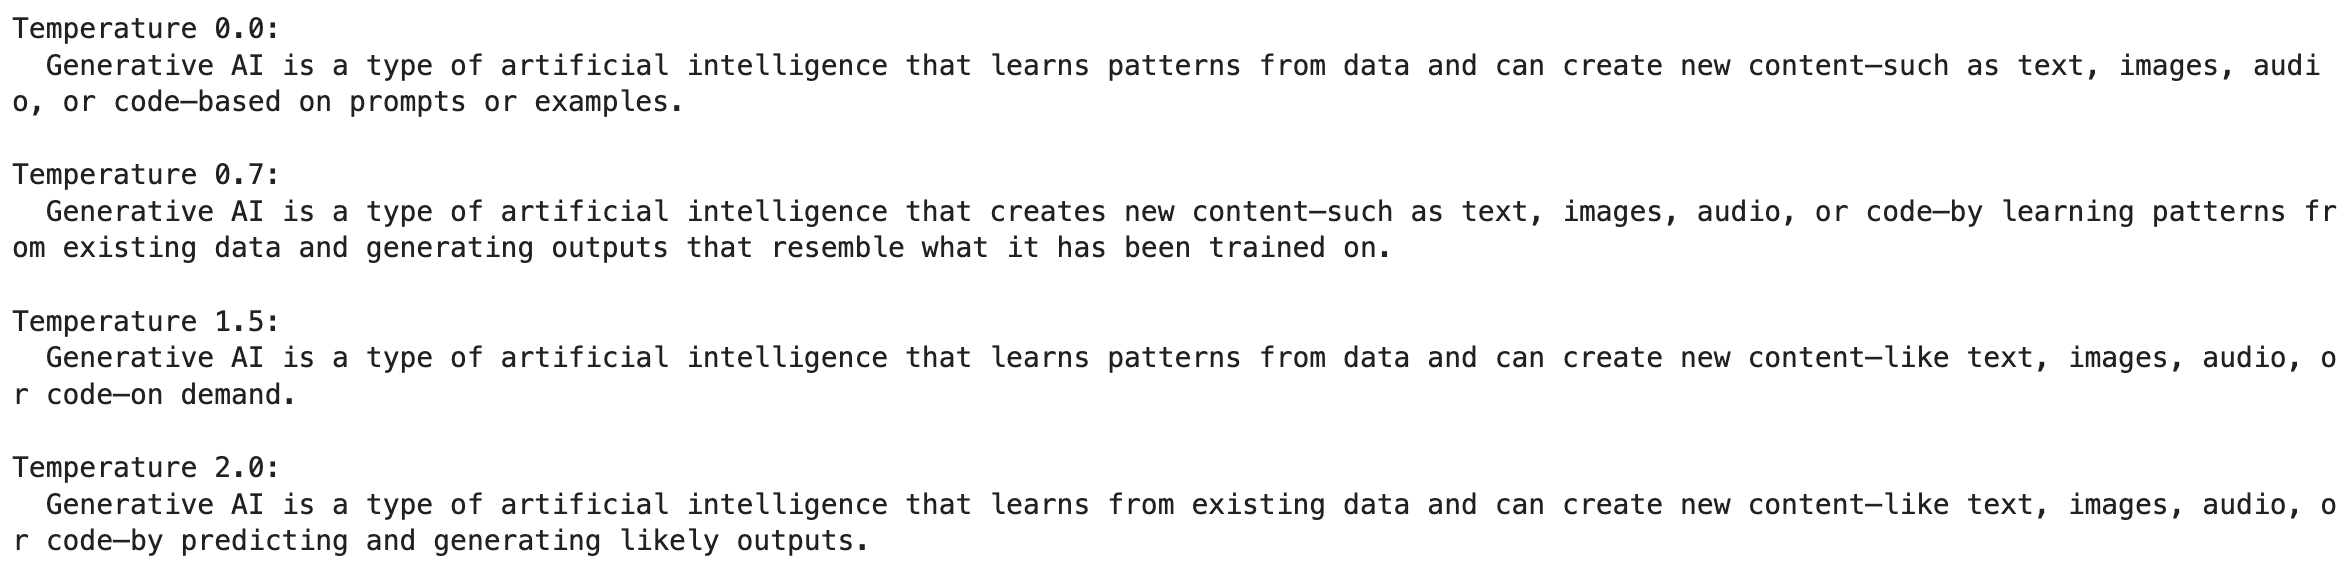

In [ ]:
prompt = 'Name the three largest retailers in the world by annual revenue.'

print('=== 3 runs at temperature=0 (near-identical; determinism is best-effort) ===')
for run in range(3):
    resp = client.chat.completions.create(
        model='gpt-5.4-nano',
        messages=[{'role': 'user', 'content': prompt}],
        max_completion_tokens=100,
        temperature=0,
    )
    print(f'  Run {run + 1}: {resp.choices[0].message.content}')

print()
print('=== 3 runs at temperature=2 (should vary) ===')
for run in range(3):
    resp = client.chat.completions.create(
        model='gpt-5.4-nano',
        messages=[{'role': 'user', 'content': prompt}],
        max_completion_tokens=100,
        temperature=2,
    )
    print(f'  Run {run + 1}: {resp.choices[0].message.content}')

In [ ]:
# Deliberately cut a response short
response_short = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'Explain the history of the barcode (UPC) in retail in detail, explain in 200 words maximum.'}],
    max_completion_tokens=300,   # Deliberately shorter than the ~260 tokens a 200-word answer needs
)

print('Response (limited to 220 tokens):')
print(response_short.choices[0].message.content)
print()
print(f'Finish reason: {response_short.choices[0].finish_reason}')
print()
print('finish_reason="stop"   -> model finished naturally')
print('finish_reason="length" -> model was cut off by max_completion_tokens')

<div class="concept-box">
<strong>When to use which temperature:</strong>
<table class="compare-table" style="margin-top: 10px;">
<tr><th>Temperature</th><th>Behaviour</th><th>Use when</th></tr>
<tr>
    <td><code>0</code></td>
    <td>Near-deterministic &mdash; runs are usually identical, but determinism is best-effort, not guaranteed (as our 3-run demo showed)</td>
    <td>Classification, data extraction, factual Q&A, production pipelines</td>
</tr>
<tr>
    <td><code>0.3 &ndash; 0.7</code></td>
    <td>Balanced creativity</td>
    <td>Customer-facing text, emails, summaries</td>
</tr>
<tr>
    <td><code>0.8 &ndash; 1.5</code></td>
    <td>Highly varied, sometimes surprising</td>
    <td>Brainstorming, creative writing, generating diverse options</td>
</tr>
</table>
</div>

<div class="concept-box">
<strong>top_p</strong> is another parameter that controls randomness (nucleus sampling). In practice, adjust <strong>either</strong> temperature or top_p, not both at once. Temperature is more intuitive, so we will use it throughout this course.
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 7 &mdash; The Model Zoo &mdash; Choosing the Right Model</strong>
</div>

OpenAI offers a family of GPT-5.x models at different price-performance points:

<table class="compare-table">
<tr><th>Model</th><th>Sweet spot</th><th>Input price (per 1M tokens)</th><th>Output price (per 1M tokens)</th></tr>
<tr><td><code>gpt-5.4-nano</code></td><td>Fast, cheap, good for simple tasks</td><td>$0.10</td><td>$0.40</td></tr>
<tr><td><code>gpt-5.4-mini</code></td><td>Balanced quality and cost</td><td>$0.40</td><td>$1.60</td></tr>
<tr><td><code>gpt-5.5</code></td><td>Flagship, best quality, highest cost</td><td>$2.50</td><td>$10.00</td></tr>
</table>

Let us run the **same 3 tasks** across all 3 models and compare quality, speed, and tokens:

In [ ]:
models = ['gpt-5.4-nano', 'gpt-5.4-mini', 'gpt-5.5']

tasks = [
    ('Factual Q&A',
     'What is SKU rationalization in retail? Answer in 2-3 sentences.'),
    ('Creative Writing',
     'Write a 2-sentence story about the first hour of Black Friday in a supercenter.'),
    ('Reasoning',
     'A store receives 120 units of a SKU, sells 45, returns 8 damaged units to the vendor, and transfers 20 to another store. How many units remain on hand? Show your reasoning step by step. dont use * while answering the text'),
]

comparison = {}
for model_name in models:
    comparison[model_name] = {}
    for task_name, prompt in tasks:
        start_t = time.time()
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{'role': 'user', 'content': prompt}],
            max_completion_tokens=200,
        )
        elapsed_t = time.time() - start_t
        comparison[model_name][task_name] = {
            'answer': resp.choices[0].message.content,
            'total_tokens': resp.usage.total_tokens,
            'prompt_tokens': resp.usage.prompt_tokens,
            'completion_tokens': resp.usage.completion_tokens,
            'time': elapsed_t,
        }

# Print comparison
for task_name, _ in tasks:
    print(f'{"=" * 70}')
    print(f'  Task: {task_name}')
    print(f'{"=" * 70}')
    for model_name in models:
        r = comparison[model_name][task_name]
        print(f'--- {model_name}  |  {r["total_tokens"]} tokens  |  {r["time"]:.2f}s ---')
        print(r['answer'])
        print()

In [ ]:
# IMPORTANT LESSON: GPT-4.1 uses max_tokens, GPT-5.x uses max_completion_tokens

print('=== GPT-5.x: uses max_completion_tokens ===')
r5 = client.chat.completions.create(
    model='gpt-5.4-nano',
    messages=[{'role': 'user', 'content': 'Say hello!'}],
    max_completion_tokens=50,   # <-- GPT-5.x parameter
)
print(f'  gpt-5.4-nano: {r5.choices[0].message.content}')

print()
print('=== GPT-4.1: uses max_tokens ===')
r4 = client.chat.completions.create(
    model='gpt-4.1-nano',
    messages=[{'role': 'user', 'content': 'Say hello!'}],
    max_tokens=50,              # <-- GPT-4.1 parameter
)
print(f'  gpt-4.1-nano: {r4.choices[0].message.content}')

print()
print('If you use max_tokens with a GPT-5.x model, you will get an error.')
print('If you find old tutorials online, watch for this difference.')

<div class="takeaway">
<strong>Model selection rule of thumb:</strong>
<ol style="margin: 8px 0 0 0;">
<li>Start with <code>gpt-5.4-nano</code> — it is fast, cheap, and surprisingly capable.</li>
<li>Move to <code>gpt-5.4-mini</code> only when nano fails your quality bar on a specific task.</li>
<li>Use <code>gpt-5.5</code> for tasks that genuinely need the best reasoning — complex analysis, nuanced writing, multi-step logic.</li>
<li>For legacy projects, <code>gpt-4.1-nano</code> still works but remember to use <code>max_tokens</code> instead of <code>max_completion_tokens</code>.</li>
</ol>
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Part 8 &mdash; The Cost Math</strong>
</div>

Let us calculate the real monthly cost of using the API at different scales, and compare to a ChatGPT Plus subscription.

**Assumptions:**
- Average call: ~200 input tokens, ~300 output tokens (typical for a Q&A or classification task)
- ChatGPT Plus subscription: approximately Rs 1,650/month
- Exchange rate: ~Rs 85 per USD

In [ ]:
# Pricing per 1M tokens (USD)
pricing = {
    'gpt-5.4-nano': {'input': 0.10, 'output': 0.40},
    'gpt-5.4-mini': {'input': 0.40, 'output': 1.60},
    'gpt-5.5':      {'input': 2.50, 'output': 10.00},
}

AVG_INPUT  = 200   # tokens per call
AVG_OUTPUT = 300   # tokens per call
INR = 85           # INR per USD
CHATGPT_PLUS = 1650  # INR per month

usage_levels = [
    ('Light',  50),     # calls per day
    ('Medium', 200),
    ('Heavy',  1000),
]

# Header
print(f'{"Usage":<10} {"Calls/day":<12} ', end='')
for model in pricing:
    print(f'{model:<18} ', end='')
print(f'{"ChatGPT Plus":<14}')
print('-' * 88)

# Rows
for label, calls_day in usage_levels:
    calls_month = calls_day * 30
    total_in  = calls_month * AVG_INPUT  / 1_000_000   # in millions
    total_out = calls_month * AVG_OUTPUT / 1_000_000

    print(f'{label:<10} {calls_day:<12} ', end='')
    for model, prices in pricing.items():
        cost_usd = total_in * prices['input'] + total_out * prices['output']
        cost_inr = cost_usd * INR
        print(f'Rs {cost_inr:>10,.2f}    ', end='')
    print(f'Rs {CHATGPT_PLUS:>8,}')

print()
print('Observations:')
print('  - gpt-5.4-nano at HEAVY use (1000 calls/day) costs Rs ~357/month')
print('    That is 5x cheaper than ChatGPT Plus.')
print('  - gpt-5.5 at heavy use costs Rs ~8,925/month')
print('    That is 5x MORE than ChatGPT Plus.')
print('  - For automation at scale, nano is unbeatable.')

<div class="concept-box">
<strong>When API is cheaper vs when the subscription wins:</strong>
<table class="compare-table" style="margin-top: 10px;">
<tr><th>Scenario</th><th>API or Subscription?</th><th>Why</th></tr>
<tr>
    <td>Automated classification of 1,000 inputs/day</td>
    <td><strong>API</strong> (nano)</td>
    <td>Rs 357/month vs Rs 1,650. API is 5x cheaper, and it runs unattended.</td>
</tr>
<tr>
    <td>Daily personal assistant for emails and research</td>
    <td><strong>Subscription</strong></td>
    <td>ChatGPT gives you web browsing, file upload, memory, and rendering — all included.</td>
</tr>
<tr>
    <td>Building a customer service chatbot</td>
    <td><strong>API</strong> (nano/mini)</td>
    <td>You cannot embed ChatGPT into your app. API is the only option.</td>
</tr>
<tr>
    <td>Heavy research with flagship model</td>
    <td><strong>Subscription</strong></td>
    <td>GPT-5.5 at volume gets expensive fast. Subscription includes flagship access.</td>
</tr>
</table>
</div>

<div class="takeaway">
<strong>Rule:</strong> For light use, API wins. For heavy interactive use, the subscription may be better. For automation at scale, API is the <strong>only</strong> option.
</div>

<hr class="section-divider">

<div class="topic-header">
<strong>Wrap-up &mdash; Everything We Learned</strong>
</div>

<div class="diagram-box">
<p style="font-size: 14px; color: #1a3a4a; margin-bottom: 16px;"><strong>Notebook 1.1 at a glance:</strong></p>
<table style="margin: 0 auto; border-collapse: separate; border-spacing: 8px;">
<tr>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Why API?</strong><br>
        <span style="font-size: 11px;">Automation, scale,<br>integration, control</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Tokens</strong><br>
        <span style="font-size: 11px;">Models see numbers,<br>not text. Pay per token.</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>API Anatomy</strong><br>
        <span style="font-size: 11px;">model, messages,<br>max_completion_tokens,<br>temperature</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Roles</strong><br>
        <span style="font-size: 11px;">system = persona<br>user = question<br>assistant = answer</span>
    </td>
</tr>
<tr>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Tradeoffs</strong><br>
        <span style="font-size: 11px;">No memory, no web,<br>no formatting,<br>you handle errors</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Temperature</strong><br>
        <span style="font-size: 11px;">0 = deterministic<br>0.7 = balanced<br>1.5 = creative</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Model Zoo</strong><br>
        <span style="font-size: 11px;">nano &rarr; mini &rarr; 5.5<br>Start small,<br>scale up if needed</span>
    </td>
    <td class="flow-step" style="vertical-align: top; width: 150px;">
        <strong>Cost</strong><br>
        <span style="font-size: 11px;">Pay per token.<br>nano is 5x cheaper<br>than ChatGPT Plus.</span>
    </td>
</tr>
</table>
</div>

<div class="concept-box">
<strong>Key takeaways:</strong>
<ol style="margin: 8px 0 0 0; line-height: 1.8;">
<li>The API gives you what ChatGPT cannot: <strong>automation</strong> (loops over thousands of inputs), <strong>integration</strong> (embed AI in your apps), and <strong>control</strong> (exact parameters, reproducible results).</li>
<li>Every API call is <strong>stateless</strong> — the model has no memory between calls. You must manage conversation history yourself.</li>
<li>The <strong>system prompt</strong> is your most powerful tool — same model, same question, completely different behaviour.</li>
<li><strong>Temperature = 0</strong> for production pipelines. Higher temperatures for brainstorming and creative work.</li>
<li>Start with <strong>gpt-5.4-nano</strong>. Move up only when quality demands it.</li>
<li>GPT-5.x models use <code>max_completion_tokens</code>, not <code>max_tokens</code>. Watch for this when reading older tutorials.</li>
<li>Always set <code>max_completion_tokens</code> and estimate cost before running large batches.</li>
</ol>
</div>

<div class="takeaway">
<strong>The honest summary:</strong><br><br>
API gives you <strong>power</strong> — automation, control, integration.<br>
But it takes away <strong>convenience</strong> — memory, formatting, web browsing, error handling.<br><br>
The rest of this course teaches you how to <strong>get the convenience back while keeping the power.</strong>
<ul style="margin: 10px 0 0 0;">
<li><strong>E02</strong> — Zero-Shot vs Few-Shot Prompting: how to talk to models well</li>
<li><strong>Day 2</strong> — RAG: how to give LLMs access to your documents and data</li>
<li><strong>Day 3&ndash;4</strong> — Tools, MCP, and Agents: how to give LLMs the ability to act</li>
<li><strong>Day 5</strong> — Production: how to make it all reliable, safe, and scalable</li>
</ul>
</div>

<hr class="section-divider">
<p style="text-align: center; color: #888; font-size: 12px;">
<strong>Next:</strong> E02 &middot; Zero-Shot vs Few-Shot Prompting &mdash; <em>Now that we can talk to LLMs, how do we talk to them well?</em>
</p>

<hr class="section-divider">

<div class="topic-header">
<strong>&#128279; The gap we leave</strong>
</div>

<div class="concept-box">
This exercise proved one thing: <strong>we can call models</strong> &mdash; reliably, at scale, at a known cost. But look back at every result in this notebook. The ticket classifier only worked because we told it exactly which four categories to use. The seller-escalation answer changed completely depending on which persona we set. The fulfillment table came out in whatever shape the model felt like. Every single answer depended entirely on <strong>HOW we asked</strong> &mdash; and so far, our asking has been improvised.<br><br>
That is the gap. A team that can call the API but cannot control the ask ships a demo, not a product.<br><br>
<strong>E02 fixes exactly that:</strong> zero-shot vs few-shot prompting &mdash; the first deliberate technique for shaping what the model does, and the next rung on the Context Ladder.
</div>